In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
import random
from tqdm import tqdm
import torch
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms


In [85]:
# create animations of image transformations
def create_video(filename, fps, shape):
    return cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, (shape[1], shape[0]))

def draw_text(img, text):
    cv2.putText(img, text, (10, img.shape[0]-10), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 0), 5)
    cv2.putText(img, text, (10, img.shape[0]-10), cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 255, 255), 3)

def show_video(filename, width=640):
    tmp_mp4 = f"{filename[:-4]}_H264{filename[-4:]}"
    os.system(f"ffmpeg -i {filename} -vcodec libx264 {tmp_mp4}")
    os.remove(filename)
    os.rename(tmp_mp4, filename)
    display(Video(filename, embed=True, width=width))


In [86]:
# 2D Flow Matching Example
# This demonstrates flow matching: transforming noise to data via learned vector fields

import os
from IPython.display import HTML, Video, display
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.patches as patches


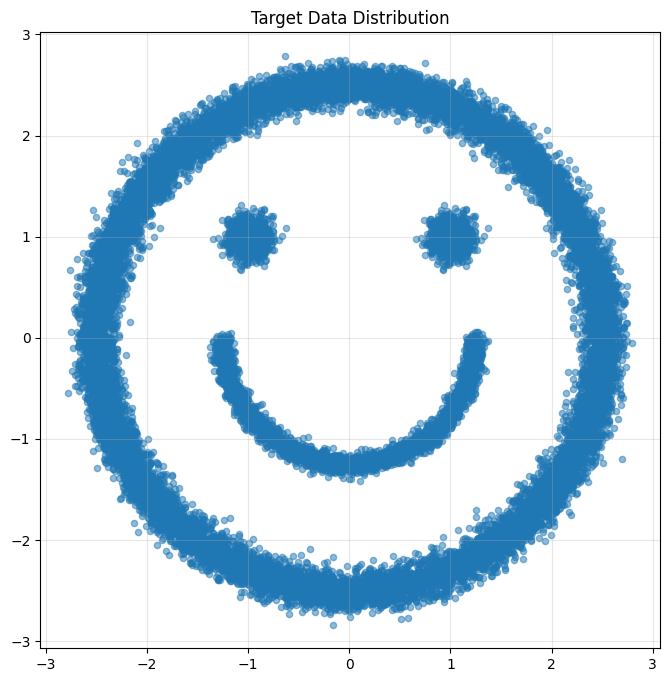

In [ ]:
# Create a simple 2D dataset
def create_dataset(n_samples=1000, radius=2.0):
    num_face = n_samples*8//10
    angles = np.linspace(0, 2*np.pi, num_face)
    x = radius * np.cos(angles) + np.random.randn(num_face) * 0.1
    y = radius * np.sin(angles) + np.random.randn(num_face) * 0.1
    face = np.stack([x, y], axis=1)

    num_eyes = n_samples*1//20
    x = np.random.randn(num_eyes) * 0.1
    y = np.random.randn(num_eyes) * 0.1
    left_eye = np.stack([-1+x, 1+y], axis=1)
    right_eye = np.stack([1+x, 1+y], axis=1)
    eyes = np.concatenate([left_eye, right_eye], axis=0)

    # Create a mouth
    num_mouth = n_samples - num_face - num_eyes
    mouth_angles = np.linspace(np.pi, 2*np.pi, num_mouth)
    mouth_x = radius*0.5*np.cos(mouth_angles) + np.random.randn(num_mouth) * 0.05
    mouth_y = radius*0.5*np.sin(mouth_angles) + np.random.randn(num_mouth) * 0.05
    mouth = np.stack([mouth_x, mouth_y], axis=1)

    return np.concatenate([face, eyes, mouth], axis=0)

# Create dataset
data = create_dataset(n_samples=20000, radius=2.5)

# Visualize the dataset
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, s=20)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid(True, alpha=0.3)
plt.title('Target Data Distribution')
plt.axis('equal')
plt.show()


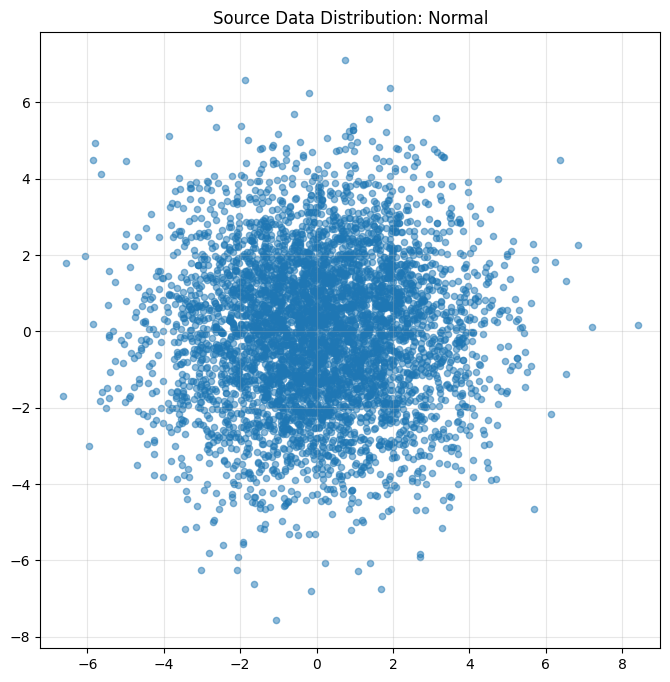

In [101]:
data = np.random.randn(5000, 2) * 2.0

# Visualize the dataset
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, s=20)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid(True, alpha=0.3)
plt.title('Source Data Distribution: Normal')
plt.axis('equal')
plt.show()

In [88]:
# Simple neural network for velocity field
class VelocityField(torch.nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3*3*5, hidden_dim),  # 2D position + time
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 2)  # 2D velocity
        )

    def pos_enc(self, x, max_freq=5):
        """x: [batch, 3] - positional encoding with geometric frequency progression"""
        # Standard positional encoding: use frequencies 2^0, 2^1, 2^2, ..., 2^(max_freq-1)
        # Or alternatively: base^i where base is typically 2 or a learned parameter
        x = x.unsqueeze(-1)  # [batch, 3, 1]
        
        # Create frequencies: [1, 2, 4, 8, ..., 2^(max_freq-1)]
        # Using 2^i gives geometric progression (standard in NeRF, etc.)
        freqs = 2.0 ** torch.arange(0, max_freq, 1, device=x.device, dtype=x.dtype)
        
        # Multiply input by each frequency: [batch, 3, max_freq]
        x_scaled = x * freqs.unsqueeze(0)  # Broadcasting: [batch, 3, 1] * [1, max_freq]
        
        # For each frequency, compute sin and cos
        # This gives us [batch, 3, max_freq] for sin and [batch, 3, max_freq] for cos
        sin_x = torch.sin(x_scaled)  # [batch, 3, max_freq]
        cos_x = torch.cos(x_scaled)  # [batch, 3, max_freq]
        
        # Concatenate: original x (repeated), sin, cos
        # Result: [batch, 3, 3*max_freq] = [batch, 3, 30] for max_freq=10
        x = torch.cat([x.expand(-1, -1, max_freq), sin_x, cos_x], dim=-1)
        
        return x
    
    def forward(self, x, t):
        """x: [batch, 2], t: [batch, 1]"""
        t = t.unsqueeze(-1) if t.dim() == 1 else t
        inp = torch.cat([x, t], dim=-1)
        inp = self.pos_enc(inp)
        return self.net(inp.view(inp.shape[0], -1))

# Initialize model
velocity_model = VelocityField(hidden_dim=128)
print(f"Model parameters: {sum(p.numel() for p in velocity_model.parameters())}")


Model parameters: 39170


In [89]:
# Flow Matching Training
# We use conditional flow matching: learn to transform x0 (noise) to x1 (data)

def flow_matching_loss(model, x0, x1, t):
    """
    Flow matching loss: ||v_theta(x_t, t) - u_t(x_t)||^2
    where u_t is the conditional flow from x0 to x1
    """
    # Linear interpolation: x_t = (1-t)*x0 + t*x1
    x_t = (1 - t.unsqueeze(-1)) * x0 + t.unsqueeze(-1) * x1
    
    # True velocity: u_t = x1 - x0 (for linear path)
    u_t = x1 - x0
    
    # Predicted velocity
    v_pred = model(x_t, t)
    
    # MSE loss
    loss = torch.mean((v_pred - u_t) ** 2)
    return loss

# Training loop
optimizer = torch.optim.Adam(velocity_model.parameters(), lr=1e-3)
n_epochs = 5000
batch_size = 256

data_tensor = torch.FloatTensor(data)

tq = tqdm(range(n_epochs))
for epoch in tq:
    # Sample batch
    idx = torch.randint(0, len(data), (batch_size,))
    x1 = data_tensor[idx]  # data samples
    x0 = torch.randn(batch_size, 2) * 2.0  # noise samples
    t = torch.rand(batch_size)  # random time
    
    # Compute loss
    loss = flow_matching_loss(velocity_model, x0, x1, t)
    
    # Update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    tq.set_postfix(loss=loss.item())
    #if (epoch + 1) % 100 == 0:
    #    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

print("Training complete!")


100%|██████████| 5000/5000 [00:22<00:00, 221.92it/s, loss=5.08]

Training complete!


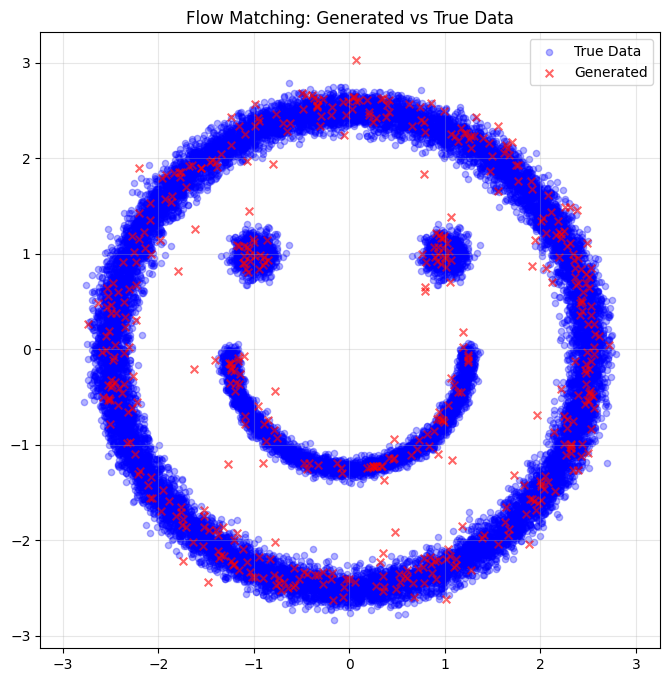

In [96]:
# Generate samples by integrating the ODE: dx/dt = v(x, t)
def generate_samples(model, n_samples=100, n_steps=100):
    """Generate samples by solving ODE from t=0 to t=1"""
    model.eval()
    
    # Start from noise
    x = torch.randn(n_samples, 2) * 2.0
    
    # Store trajectory
    trajectory = [x.detach().numpy().copy()]
    
    dt = 1.0 / n_steps
    
    with torch.no_grad():
        for i in range(n_steps):
            t = torch.ones(n_samples) * (i * dt)
            v = model(x, t)
            x = x + v * dt
            trajectory.append(x.detach().numpy().copy())
    
    return trajectory

# Generate samples
trajectory = generate_samples(velocity_model, n_samples=500, n_steps=100)
final_samples = trajectory[-1]

# Visualize generated samples
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, s=20, label='True Data', c='blue')
plt.scatter(final_samples[:, 0], final_samples[:, 1], alpha=0.6, s=30, label='Generated', c='red', marker='x')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Flow Matching: Generated vs True Data')
plt.axis('equal')
plt.show()


In [91]:
# Animation 1: Sample trajectories from noise to data
def animate_trajectories(trajectory, data, filename='flow_matching_trajectories.gif'):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot data distribution
    ax.scatter(data[:, 0], data[:, 1], alpha=0.2, s=20, c='blue', label='Target Distribution')
    
    # Initialize plot elements
    scatter = ax.scatter([], [], s=50, c='red', alpha=0.7, label='Samples')
    lines = [ax.plot([], [], 'r-', alpha=0.3, linewidth=1)[0] for _ in range(len(trajectory[0]))]
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title('Flow Matching: Transforming Noise to Data')
    
    def animate(frame):
        # Update scatter
        scatter.set_offsets(trajectory[frame])
        
        # Update trajectory lines
        for i, line in enumerate(lines):
            if frame > 0:
                x_data = [traj[i, 0] for traj in trajectory[:frame+1]]
                y_data = [traj[i, 1] for traj in trajectory[:frame+1]]
                line.set_data(x_data, y_data)
        
        ax.set_title(f'Flow Matching: t = {frame/len(trajectory):.2f}')
        return [scatter] + lines
    
    anim = FuncAnimation(fig, animate, frames=len(trajectory), interval=50, blit=True, repeat=True)
    anim.save(filename, writer=PillowWriter(fps=20))
    plt.close()
    return filename

# Create trajectory animation
traj_file = animate_trajectories(trajectory, data)
print(f"Animation saved: {traj_file}")
display(HTML(f'<img src="{traj_file}">'))


Animation saved: flow_matching_trajectories.gif


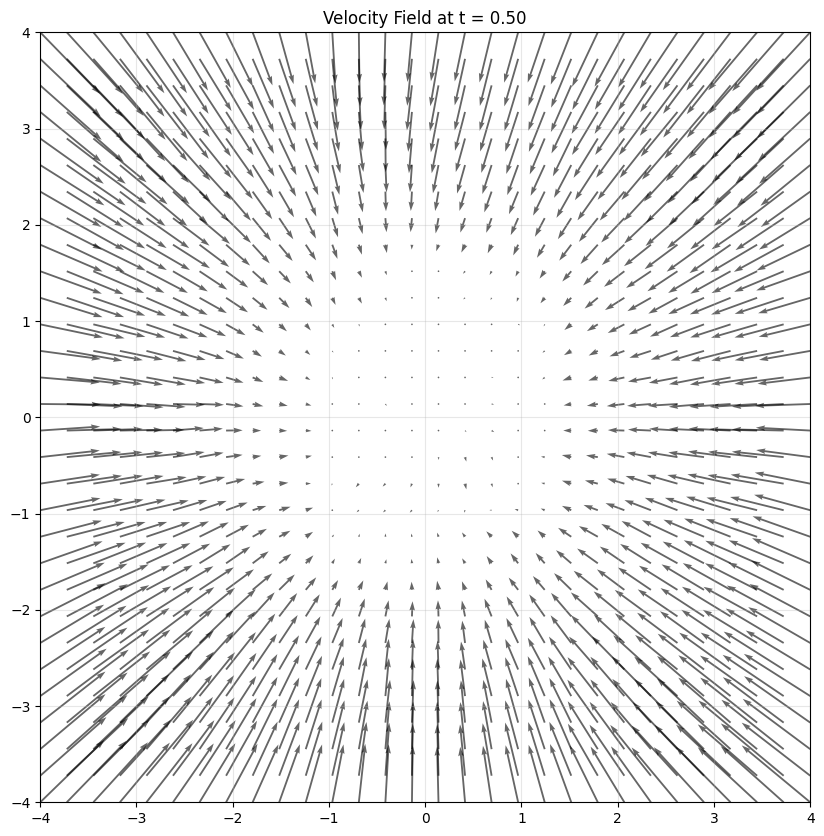

In [92]:
# Animation 2: Vector field visualization at different time steps
def visualize_vector_field(model, t_val, filename=None):
    """Visualize the learned velocity field at time t"""
    model.eval()
    
    # Create grid
    x = np.linspace(-4, 4, 30)
    y = np.linspace(-4, 4, 30)
    X, Y = np.meshgrid(x, y)
    
    # Compute velocities
    grid_points = torch.FloatTensor(np.stack([X.ravel(), Y.ravel()], axis=1))
    t = torch.ones(len(grid_points)) * t_val
    
    with torch.no_grad():
        velocities = model(grid_points, t).numpy()
    
    scale = 0.1
    U = velocities[:, 0].reshape(X.shape) * scale
    V = velocities[:, 1].reshape(X.shape) * scale
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=0.5, alpha=0.6)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Velocity Field at t = {t_val:.2f}')
    
    if filename:
        plt.savefig(filename, dpi=100, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# Visualize vector field at different times
for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    visualize_vector_field(velocity_model, t, filename=f'vector_field_t{t:.2f}.png')
    
# Show one example
visualize_vector_field(velocity_model, 0.5)


In [93]:
# Animation 3: Vector field evolution over time
def animate_vector_field(model, filename='flow_matching_vector_field.gif'):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create grid
    x = np.linspace(-4, 4, 30)
    y = np.linspace(-4, 4, 30)
    X, Y = np.meshgrid(x, y)
    
    grid_points = torch.FloatTensor(np.stack([X.ravel(), Y.ravel()], axis=1))
    
    quiver = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=0.5, alpha=0.6)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    def animate(t_val):
        t = torch.ones(len(grid_points)) * t_val
        with torch.no_grad():
            velocities = model(grid_points, t).numpy()
        
        scale = 0.1
        U = velocities[:, 0].reshape(X.shape) * scale
        V = velocities[:, 1].reshape(X.shape) * scale
        
        ax.clear()
        ax.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=0.5, alpha=0.6, color='blue')
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'Velocity Field Evolution: t = {t_val:.2f}')
        return []
    
    anim = FuncAnimation(fig, animate, frames=np.linspace(0, 1, 50), interval=100, blit=False, repeat=True)
    anim.save(filename, writer=PillowWriter(fps=10))
    plt.close()
    return filename

# Create vector field animation
vf_file = animate_vector_field(velocity_model)
print(f"Vector field animation saved: {vf_file}")
display(HTML(f'<img src="{vf_file}">'))


Vector field animation saved: flow_matching_vector_field.gif


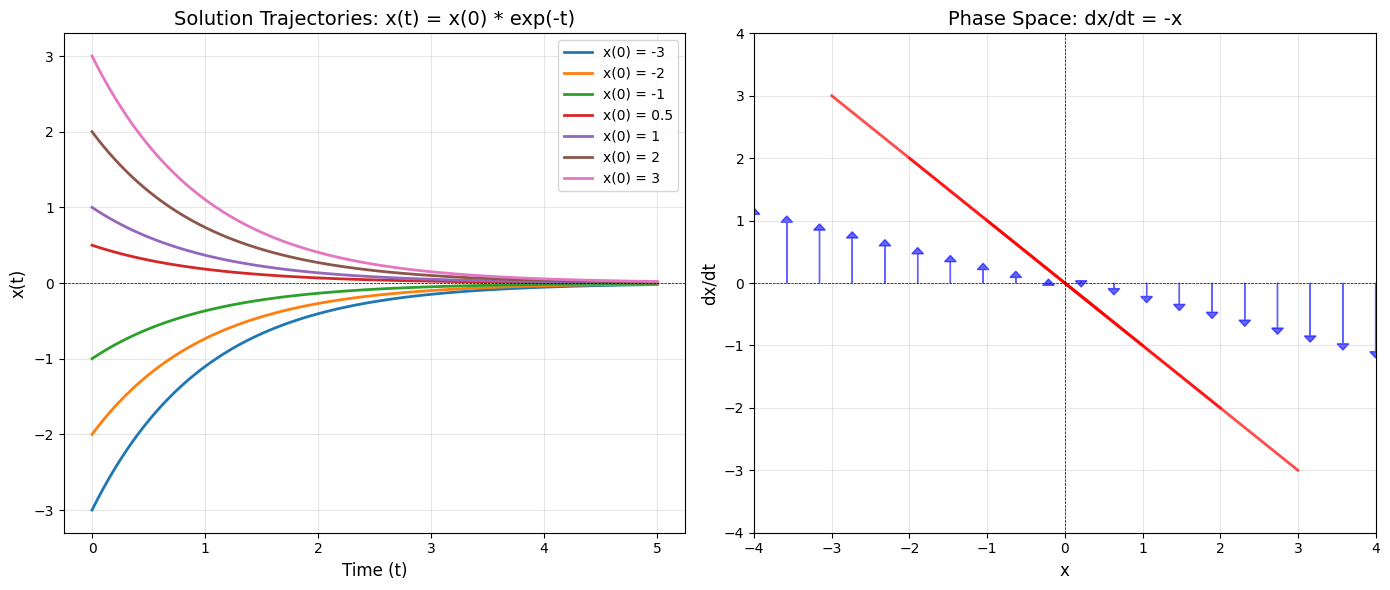

Analytical solution: x(t) = x(0) * exp(-t)
All solutions decay exponentially to zero.


In [102]:
# Simple ODE Visualization: dx/dt = -x
# This demonstrates a simple first-order ODE with analytical solution x(t) = x(0) * exp(-t)

from scipy.integrate import odeint

# Define the ODE: dx/dt = -x
def ode_system(x, t):
    """ODE: dx/dt = -x"""
    return -x

# Time points for integration
t = np.linspace(0, 5, 100)

# Solve for different initial conditions
initial_conditions = [-3, -2, -1, 0.5, 1, 2, 3]
solutions = []
for x0 in initial_conditions:
    sol = odeint(ode_system, x0, t)
    solutions.append(sol.flatten())

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Solution trajectories over time
ax1 = axes[0]
for i, (x0, sol) in enumerate(zip(initial_conditions, solutions)):
    ax1.plot(t, sol, label=f'x(0) = {x0}', linewidth=2)
ax1.set_xlabel('Time (t)', fontsize=12)
ax1.set_ylabel('x(t)', fontsize=12)
ax1.set_title('Solution Trajectories: x(t) = x(0) * exp(-t)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Right plot: Phase space / Vector field
ax2 = axes[1]
# Create vector field
x_range = np.linspace(-4, 4, 20)
# For 1D ODE, we visualize in 2D: x vs dx/dt
X = np.array([x_range])
Y = np.array([-x_range])  # dx/dt = -x

# Plot vector field (as arrows)
for x_val in x_range:
    if abs(x_val) > 0.1:  # Skip very small values to avoid clutter
        ax2.arrow(x_val, 0, 0, -x_val * 0.3, head_width=0.15, head_length=0.1, 
                 fc='blue', ec='blue', alpha=0.6, length_includes_head=True)

# Plot solution trajectories in phase space
for x0, sol in zip(initial_conditions, solutions):
    # In phase space: x vs dx/dt = -x
    dx_dt = -sol
    ax2.plot(sol, dx_dt, 'r-', linewidth=2, alpha=0.7)

ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('dx/dt', fontsize=12)
ax2.set_title('Phase Space: dx/dt = -x', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax2.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)

plt.tight_layout()
plt.show()

# Print analytical solution
print("Analytical solution: x(t) = x(0) * exp(-t)")
print("All solutions decay exponentially to zero.")


Euler's method animation saved: euler_method_animation.gif


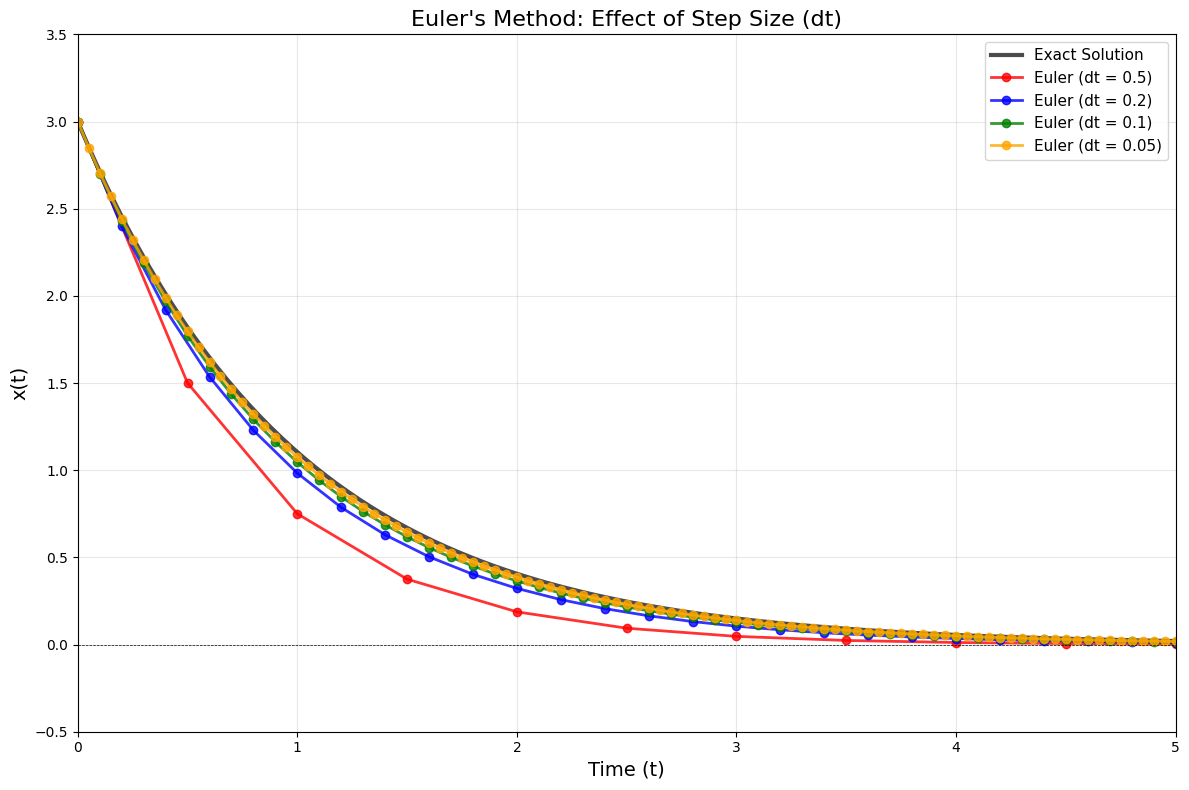


Note: Smaller step sizes (dt) give more accurate approximations but require more steps.


In [103]:
# Euler's Method Animation for dx/dt = -x
# This demonstrates how Euler's method approximates the solution step by step

def euler_method(ode_func, x0, t_span, dt):
    """
    Euler's method: x(t+dt) = x(t) + dt * dx/dt
    """
    t_values = np.arange(t_span[0], t_span[1] + dt, dt)
    x_values = [x0]
    x = x0
    
    for t in t_values[:-1]:
        dx_dt = ode_func(x, t)
        x = x + dt * dx_dt
        x_values.append(x)
    
    return np.array(t_values), np.array(x_values)

# Parameters
x0 = 3.0  # Initial condition
t_max = 5.0
dt = 0.2  # Step size for Euler's method

# Exact solution
t_exact = np.linspace(0, t_max, 200)
x_exact = x0 * np.exp(-t_exact)

# Euler's method solution
t_euler, x_euler = euler_method(ode_system, x0, [0, t_max], dt)

# Create animation
fig, ax = plt.subplots(figsize=(12, 8))

# Plot exact solution (full line, gray)
exact_line, = ax.plot(t_exact, x_exact, 'k-', linewidth=2, label='Exact Solution: x(t) = x(0) * exp(-t)', alpha=0.5)

# Initialize plot elements for Euler's method
euler_line, = ax.plot([], [], 'r-', linewidth=2, label='Euler Method Approximation', marker='o', markersize=8)
euler_points, = ax.plot([], [], 'ro', markersize=10, label='Euler Steps')
current_point, = ax.plot([], [], 'go', markersize=15, label='Current Step')

# Add text annotation for current step info
step_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlim(0, t_max)
ax.set_ylim(-0.5, x0 + 0.5)
ax.set_xlabel('Time (t)', fontsize=14)
ax.set_ylabel('x(t)', fontsize=14)
ax.set_title('Euler\'s Method: dx/dt = -x', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=11)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

def animate(frame):
    # Show progress up to current frame
    n_steps = min(frame + 1, len(t_euler))
    
    if n_steps > 0:
        # Update Euler line and points
        euler_line.set_data(t_euler[:n_steps], x_euler[:n_steps])
        euler_points.set_data(t_euler[:n_steps], x_euler[:n_steps])
        
        # Highlight current point
        if n_steps > 0:
            current_point.set_data([t_euler[n_steps-1]], [x_euler[n_steps-1]])
            
            # Calculate error
            t_current = t_euler[n_steps-1]
            x_exact_current = x0 * np.exp(-t_current)
            error = abs(x_euler[n_steps-1] - x_exact_current)
            
            # Update text
            step_text.set_text(f'Step: {n_steps-1}/{len(t_euler)-1}\n'
                             f't = {t_current:.2f}\n'
                             f'x_euler = {x_euler[n_steps-1]:.4f}\n'
                             f'x_exact = {x_exact_current:.4f}\n'
                             f'Error = {error:.4f}\n'
                             f'dt = {dt:.2f}')
        else:
            current_point.set_data([], [])
            step_text.set_text('')
    
    return [euler_line, euler_points, current_point, step_text]

# Create animation
anim = FuncAnimation(fig, animate, frames=len(t_euler), interval=300, blit=True, repeat=True)

# Save animation
euler_filename = 'euler_method_animation.gif'
anim.save(euler_filename, writer=PillowWriter(fps=3))
plt.close()

print(f"Euler's method animation saved: {euler_filename}")
display(HTML(f'<img src="{euler_filename}">'))

# Also create a comparison plot showing different step sizes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot exact solution
ax.plot(t_exact, x_exact, 'k-', linewidth=3, label='Exact Solution', alpha=0.7)

# Compare different step sizes
step_sizes = [0.5, 0.2, 0.1, 0.05]
colors = ['red', 'blue', 'green', 'orange']
for dt_val, color in zip(step_sizes, colors):
    t_euler_comp, x_euler_comp = euler_method(ode_system, x0, [0, t_max], dt_val)
    ax.plot(t_euler_comp, x_euler_comp, 'o-', color=color, linewidth=2, 
            markersize=6, label=f'Euler (dt = {dt_val})', alpha=0.8)

ax.set_xlim(0, t_max)
ax.set_ylim(-0.5, x0 + 0.5)
ax.set_xlabel('Time (t)', fontsize=14)
ax.set_ylabel('x(t)', fontsize=14)
ax.set_title('Euler\'s Method: Effect of Step Size (dt)', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=11)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nNote: Smaller step sizes (dt) give more accurate approximations but require more steps.")
